<a href="https://colab.research.google.com/github/nknak-crypto/Machine-Learning-Supervisado/blob/main/Grupo_9_TP4_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico N°3 — Machine Learning Supervisado 2026
GRUPO 9: Knak, Guasti & Vicente

## Consigna:

•Construir un modelo de Predicción

•Generar métricas de clasificación

•Matriz de Confusión y métricas relevantes

In [1]:
# Celda 1 - Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

from IPython.display import display, HTML

print("✅ Librerias importadas correctamente")

✅ Librerias importadas correctamente


In [3]:
# Celda 2 - Cargar datos
df = pd.read_csv('TP Breast_Cancer.csv')

display(HTML("<h3 style='color:#3C3489'>Vista general del dataset</h3>"))
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
display(df.head())

Filas: 4024 | Columnas: 16


,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


Age                        int64
Race                      object
Marital Status            object
T Stage                   object
N Stage                   object
6th Stage                 object
differentiate             object
Grade                     object
A Stage                   object
Tumor Size                 int64
Estrogen Status           object
Progesterone Status       object
Regional Node Examined     int64
Reginol Node Positive      int64
Survival Months            int64
Status                    object
dtype: object

Valores nulos por columna:
Age                       0
Race                      0
Marital Status            0
T Stage                   0
N Stage                   0
6th Stage                 0
differentiate             0
Grade                     0
A Stage                   0
Tumor Size                0
Estrogen Status           0
Progesterone Status       0
Regional Node Examined    0
Reginol Node Positive     0
Survival Months           0
Status    

Status
Alive    3408
Dead      616
Name: count, dtype: int64



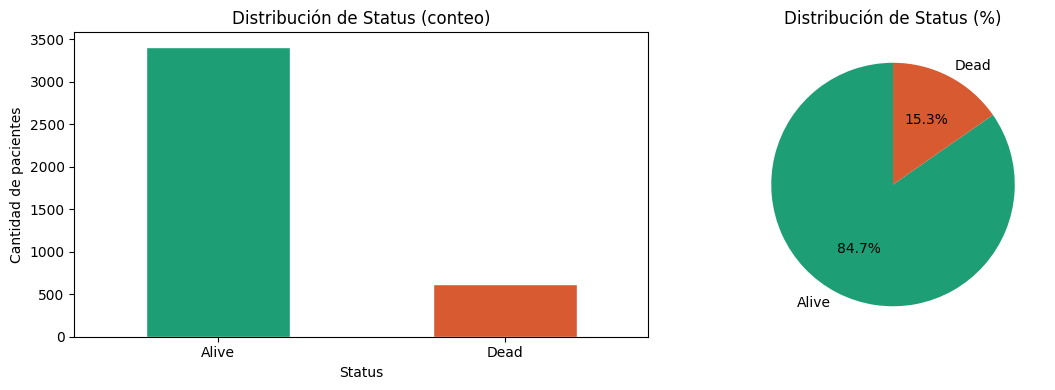

In [4]:
# Celda 3 - EDA
display(HTML("<h3 style='color:#3C3489'>Tipos de variables y valores nulos</h3>"))
print(df.dtypes)
print()
print("Valores nulos por columna:")
print(df.isnull().sum())

display(HTML("<h3 style='color:#3C3489'>Variable objetivo: Status</h3>"))
print(df['Status'].value_counts())
print()

# Grafico distribución del target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
df['Status'].value_counts().plot(kind='bar', ax=axes[0], color=['#1D9E75', '#D85A30'], edgecolor='white')
axes[0].set_title('Distribución de Status (conteo)')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Cantidad de pacientes')
axes[0].tick_params(axis='x', rotation=0)

# Porcentaje
df['Status'].value_counts(normalize=True).mul(100).plot(kind='pie', ax=axes[1],
    colors=['#1D9E75', '#D85A30'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Distribución de Status (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [5]:
# Celda 4 - Variable objetivo y features

# Definir variable objetivo (Y)
# Convertimos: Alive = 0, Dead = 1
df['Status_num'] = (df['Status'] == 'Dead').astype(int)

print("Variable objetivo (Status_num):")
print(df['Status_num'].value_counts())
print()

# Definir features (X) - todas menos Status original y Status_num
features = [
    'Age', 'Race', 'Marital Status', 'T Stage ', 'N Stage',
    '6th Stage', 'differentiate', 'Grade', 'A Stage',
    'Tumor Size', 'Estrogen Status', 'Progesterone Status',
    'Regional Node Examined', 'Reginol Node Positive', 'Survival Months'
]

X = df[features].copy()
y = df['Status_num']

print(f"Forma de X: {X.shape}")
print(f"Forma de y: {y.shape}")

Variable objetivo (Status_num):
Status_num
0    3408
1     616
Name: count, dtype: int64

Forma de X: (4024, 15)
Forma de y: (4024,)


In [6]:
# Celda 5 - One-Hot Encoding de variables categoricas
# Identificar columnas categoricas
cols_cat = X.select_dtypes(include='object').columns.tolist()
print("Columnas categoricas a encodear:", cols_cat)

# Aplicar One-Hot Encoding (drop_first=True → N-1 dummies para evitar multicolinealidad)
X_encoded = pd.get_dummies(X, columns=cols_cat, drop_first=True)

print(f"\nDimensiones antes del encoding: {X.shape}")
print(f"Dimensiones despues del encoding: {X_encoded.shape}")
display(X_encoded.head())

Columnas categoricas a encodear: ['Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage', 'differentiate', 'Grade', 'A Stage', 'Estrogen Status', 'Progesterone Status']

Dimensiones antes del encoding: (4024, 15)
Dimensiones despues del encoding: (4024, 29)


,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months,Race_Other,Race_White,Marital Status_Married,Marital Status_Separated,Marital Status_Single,...,6th Stage_IIIC,differentiate_Poorly differentiated,differentiate_Undifferentiated,differentiate_Well differentiated,Grade_1,Grade_2,Grade_3,A Stage_Regional,Estrogen Status_Positive,Progesterone Status_Positive
0,68,4,24,1,60,False,True,True,False,False,...,False,True,False,False,False,False,True,True,True,True
1,50,35,14,5,62,False,True,True,False,False,...,False,False,False,False,False,True,False,True,True,True
2,58,63,14,7,75,False,True,False,False,False,...,True,False,False,False,False,True,False,True,True,True
3,58,18,2,1,84,False,True,True,False,False,...,False,True,False,False,False,False,True,True,True,True
4,47,41,3,1,50,False,True,True,False,False,...,False,True,False,False,False,False,True,True,True,True


In [7]:
# Celda 6 - Particion de datos en Training y Testing

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,       # 80% training, 20% testing
    random_state=42,     # Para reproducibilidad
    stratify=y           # Mantiene la proporcion de clases en ambos sets
)

print(f"Training set:  {X_train.shape[0]} filas ({X_train.shape[0]/len(X_encoded)*100:.1f}%)")
print(f"Testing set:   {X_test.shape[0]} filas ({X_test.shape[0]/len(X_encoded)*100:.1f}%)")
print()
print("Distribucion de clases en training:")
print(y_train.value_counts(normalize=True).round(3))
print()
print("Distribucion de clases en testing:")
print(y_test.value_counts(normalize=True).round(3))

Training set:  3219 filas (80.0%)
Testing set:   805 filas (20.0%)

Distribucion de clases en training:
Status_num
0    0.847
1    0.153
Name: proportion, dtype: float64

Distribucion de clases en testing:
Status_num
0    0.847
1    0.153
Name: proportion, dtype: float64


In [8]:
# Celda 7 - Escalado con StandardScaler

scaler = StandardScaler()

# Ajustar SOLO con training (nunca con test, para evitar data leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Escalado aplicado correctamente")
print(f"Shape training escalado: {X_train_scaled.shape}")
print(f"Shape testing escalado:  {X_test_scaled.shape}")

✅ Escalado aplicado correctamente
Shape training escalado: (3219, 29)
Shape testing escalado:  (805, 29)


In [9]:
# Celda 8 - Entrenamiento del modelo de Regresion Logistica

modelo = LogisticRegression(
    max_iter=1000,       # Iteraciones maximas para que converja
    random_state=42
)

modelo.fit(X_train_scaled, y_train)

print("✅ Modelo entrenado correctamente")
print(f"Clases: {modelo.classes_}  (0 = Alive, 1 = Dead)")

✅ Modelo entrenado correctamente
Clases: [0 1]  (0 = Alive, 1 = Dead)


In [10]:
# Celda 9 - Predicciones sobre el set de test

y_pred       = modelo.predict(X_test_scaled)          # Clase predicha (0 o 1)
y_pred_proba = modelo.predict_proba(X_test_scaled)[:, 1]  # Probabilidad de ser Dead

print("Primeras 10 predicciones:")
for i in range(10):
    print(f"  Real: {'Dead' if y_test.values[i]==1 else 'Alive':5s} | "
          f"Predicho: {'Dead' if y_pred[i]==1 else 'Alive':5s} | "
          f"Probabilidad Dead: {y_pred_proba[i]:.2f}")

Primeras 10 predicciones:
  Real: Alive | Predicho: Alive | Probabilidad Dead: 0.18
  Real: Dead  | Predicho: Dead  | Probabilidad Dead: 0.91
  Real: Alive | Predicho: Alive | Probabilidad Dead: 0.19
  Real: Alive | Predicho: Alive | Probabilidad Dead: 0.01
  Real: Alive | Predicho: Alive | Probabilidad Dead: 0.04
  Real: Alive | Predicho: Alive | Probabilidad Dead: 0.01
  Real: Alive | Predicho: Alive | Probabilidad Dead: 0.06
  Real: Alive | Predicho: Alive | Probabilidad Dead: 0.10
  Real: Dead  | Predicho: Alive | Probabilidad Dead: 0.22
  Real: Alive | Predicho: Alive | Probabilidad Dead: 0.04


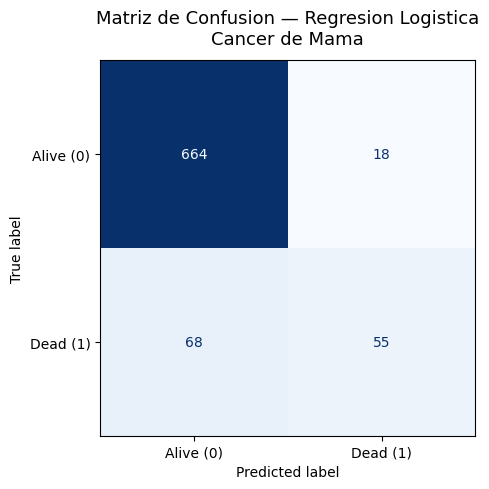


Verdaderos Negativos (TN) — Predijo Alive, era Alive: 664
Falsos Positivos    (FP) — Predijo Dead,  era Alive: 18
Falsos Negativos    (FN) — Predijo Alive, era Dead:  68
Verdaderos Positivos(TP) — Predijo Dead,  era Dead:  55


In [11]:
# Celda 10 - Matriz de Confusion

display(HTML("<h3 style='color:#3C3489'>Matriz de Confusion</h3>"))

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Alive (0)', 'Dead (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusion — Regresion Logistica\nCancer de Mama', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

# Extraer valores
tn, fp, fn, tp = cm.ravel()
print(f"\nVerdaderos Negativos (TN) — Predijo Alive, era Alive: {tn}")
print(f"Falsos Positivos    (FP) — Predijo Dead,  era Alive: {fp}")
print(f"Falsos Negativos    (FN) — Predijo Alive, era Dead:  {fn}")
print(f"Verdaderos Positivos(TP) — Predijo Dead,  era Dead:  {tp}")

In [12]:
# Celda 11 - Metricas de clasificacion

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc       = roc_auc_score(y_test, y_pred_proba)

display(HTML("<h3 style='color:#3C3489'>Metricas del Modelo</h3>"))

metricas = {
    'Accuracy':  accuracy,
    'Precision': precision,
    'Recall':    recall,
    'F1-Score':  f1,
    'AUC-ROC':   auc,
}

for nombre, valor in metricas.items():
    print(f"  {nombre:<12}: {valor:.4f}  ({valor*100:.2f}%)")

print()
print("Reporte completo:")
print(classification_report(y_test, y_pred, target_names=['Alive', 'Dead']))

  Accuracy    : 0.8932  (89.32%)
  Precision   : 0.7534  (75.34%)
  Recall      : 0.4472  (44.72%)
  F1-Score    : 0.5612  (56.12%)
  AUC-ROC     : 0.8527  (85.27%)

Reporte completo:
              precision    recall  f1-score   support

       Alive       0.91      0.97      0.94       682
        Dead       0.75      0.45      0.56       123

    accuracy                           0.89       805
   macro avg       0.83      0.71      0.75       805
weighted avg       0.88      0.89      0.88       805



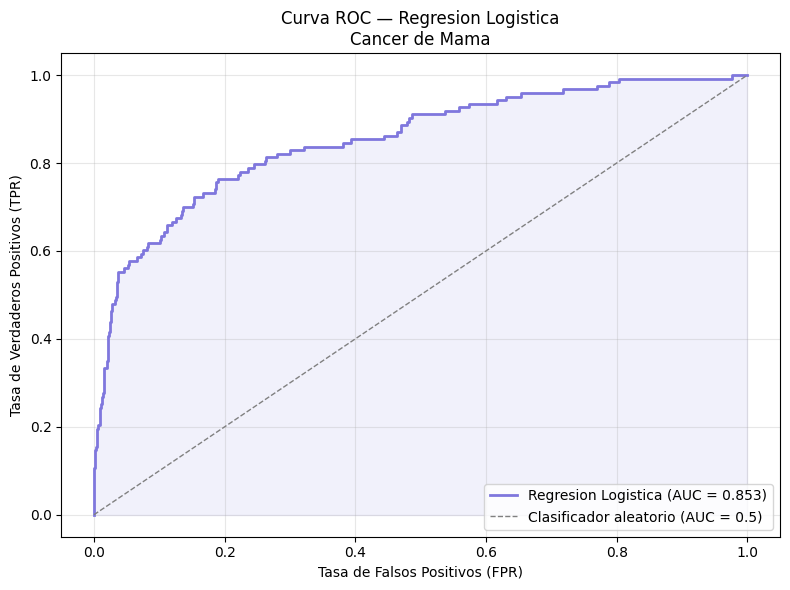

AUC = 0.8527
Interpretacion: el modelo tiene una capacidad de discriminacion del 85.3%


In [13]:
# Celda 12 - Curva ROC

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#7F77DD', lw=2,
         label=f'Regresion Logistica (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Clasificador aleatorio (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.1, color='#7F77DD')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC — Regresion Logistica\nCancer de Mama')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC = {auc:.4f}")
print("Interpretacion: el modelo tiene una capacidad de discriminacion del {:.1f}%".format(auc*100))

In [15]:
# Celda 13 - Resumen final

display(HTML("""
<div style='background:#26215C; border-left:4px solid #7F77DD; padding:15px; border-radius:8px; font-family:sans-serif; margin-bottom:16px'>
  <h3 style='color:#CECBF6; margin-top:0'>Resumen del Modelo</h3>
  <p style='color:#AFA9EC; margin:4px 0'><span style='color:#7F77DD; font-weight:bold'>Modelo:</span> Regresion Logistica</p>
  <p style='color:#AFA9EC; margin:4px 0'><span style='color:#7F77DD; font-weight:bold'>Dataset:</span> Cancer de Mama — SEER NCI (4.024 pacientes)</p>
  <p style='color:#AFA9EC; margin:4px 0'><span style='color:#7F77DD; font-weight:bold'>Variable objetivo:</span> Status (Alive=0 / Dead=1)</p>
  <p style='color:#AFA9EC; margin:4px 0'><span style='color:#7F77DD; font-weight:bold'>Split:</span> 80% training / 20% testing (estratificado)</p>
</div>
"""))

import pandas as pd

resumen = pd.DataFrame({
    'Metrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
    'Valor': [accuracy, precision, recall, f1, auc],
    'Interpretacion': [
        '% de predicciones correctas totales',
        'De los que predijo Dead, cuantos eran realmente Dead',
        'De todos los Dead reales, cuantos detecto el modelo',
        'Balance entre Precision y Recall',
        'Capacidad de separar Alive vs Dead'
    ]
})

resumen['Valor (%)'] = resumen['Valor'].apply(lambda x: f"{x*100:.2f}%")

# Colores por valor
def color_valor(val):
    try:
        num = float(val.replace('%',''))
        if num >= 80:
            return 'background-color: #04342C; color: #5DCAA5; font-weight: bold'
        elif num >= 60:
            return 'background-color: #412402; color: #EF9F27; font-weight: bold'
        else:
            return 'background-color: #501313; color: #F09595; font-weight: bold'
    except:
        return ''

styled = (
    resumen[['Metrica', 'Valor (%)', 'Interpretacion']]
    .style
    .applymap(color_valor, subset=['Valor (%)'])
    .set_properties(**{
        'background-color': '#1a1a2e',
        'color': '#e0e0e0',
        'border': '1px solid #3C3489',
        'padding': '8px 12px',
        'font-size': '13px'
    })
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#3C3489'),
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('padding', '10px 12px'),
            ('text-align', 'left'),
            ('border', '1px solid #7F77DD'),
        ]},
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'),
            ('width', '100%'),
            ('border-radius', '8px'),
            ('overflow', 'hidden'),
        ]},
    ])
)

display(styled)

/tmp/ipykernel_2306/755117074.py:45: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_valor, subset=['Valor (%)'])


,Metrica,Valor (%),Interpretacion
0,Accuracy,89.32%,% de predicciones correctas totales
1,Precision,75.34%,"De los que predijo Dead, cuantos eran realmente Dead"
2,Recall,44.72%,"De todos los Dead reales, cuantos detecto el modelo"
3,F1-Score,56.12%,Balance entre Precision y Recall
4,AUC-ROC,85.27%,Capacidad de separar Alive vs Dead


La métrica que realmente importa en este problema es el Recall, y ahí es donde el modelo muestra su principal limitación: solo detectó el 44.72% de las pacientes que efectivamente fallecieron. Dicho de otra forma, de 123 casos reales de muerte, 68 fueron clasificados incorrectamente como "Alive". En el contexto del cáncer de mama, estos Falsos Negativos representan el error más grave posible — una paciente con mal pronóstico recibe luz verde y potencialmente no accede al tratamiento que necesita a tiempo.